In [ ]:
# AutoARIMA model, currently best we have.
# TODO: cross validation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from statsforecast.adapters.prophet import AutoARIMAProphet

In [ ]:
df_pivot = pd.read_csv('Daily_Means_Through_2022_cleaned_NEW.csv')
df_pivot

In [ ]:
# housekeeping
df_pivot['date'] = pd.to_datetime(df_pivot['date'])
df_new = df_pivot.sort_values(by=['site', 'date'])
df_new

In [ ]:
# so BR is NOT continous

df = df_new[df_new['site'] == 'GD']
# drop observation if do is na
#df = df.dropna(subset=['bottom_DO_mg/L'])
df = df.dropna(subset=['surface_DO_mg/L'])
print(df.isnull().sum())
print(df)

In [ ]:
df.drop(columns=['bottom_Density_g/cm3', "surface_Density_g/cm3", "surface_Depth_m"], inplace=True)
df.isnull().sum()

In [ ]:
df.interpolate(method='linear', limit_direction='both', inplace=True)
df

In [ ]:
columns_to_shift = [col for col in df.columns if col not in ["date", "bottom_DO_mg/L", "site"]]

# Shift the selected columns back by 14 days
df_shifted = df.copy()
df_shifted[columns_to_shift] = df_shifted[columns_to_shift].shift(14)

# Drop the first 14 rows (since they now have NaN values due to shifting)
df_shifted = df_shifted.iloc[14:].reset_index(drop=True)

# Display result
print(df_shifted)

In [ ]:
#do_series = df.set_index("date")["bottom_DO_mg/L"]
do_series = df_shifted.set_index("date").drop(columns=['site'])
bottom_cols = [col for col in do_series.columns if 'bottom' in col]

do_series.drop(columns=bottom_cols, inplace=True)

do_series.dropna(inplace=True)
do_series.index = pd.DatetimeIndex(do_series.index).to_period('D')
do_series

In [ ]:
# FOR TW:
# train_data = do_series[do_series.index < '2022-01-01']
# then 1 year for future df

# FOR PD:
# train_data = do_series[do_series.index < '2020-01-01']

# for GD:
train_data = do_series[do_series.index < '2024-01-01']

#train_data = do_series



new_df = train_data.reset_index().drop(columns=['date'])
new_df['ds'] = train_data.index.to_timestamp()
#new_df.rename(columns={'bottom_DO_mg/L': 'y'}, inplace=True)
new_df.rename(columns={'surface_DO_mg/L': 'y'}, inplace=True)

new_df


In [ ]:
m = AutoARIMAProphet(changepoint_prior_scale=0.001, seasonality_prior_scale=0.01)
#m.add_regressor('surface_DO_mg/L')
# for column in new_df.columns:
#     if column != 'ds' and column != 'y':
#         m.add_regressor(column)
m.fit(new_df)

In [ ]:
# 365 for TW, 351 for PD, 336 for GD

future = m.make_future_dataframe(periods=336)
print(len(future))
print(len(do_series))
#add regressor column
# for column in new_df.columns:
#     if column != 'ds' and column != 'y':
#         future[column] = do_series[column].values
future.tail()

In [ ]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

In [ ]:
#forecast = m.predict(new_df)

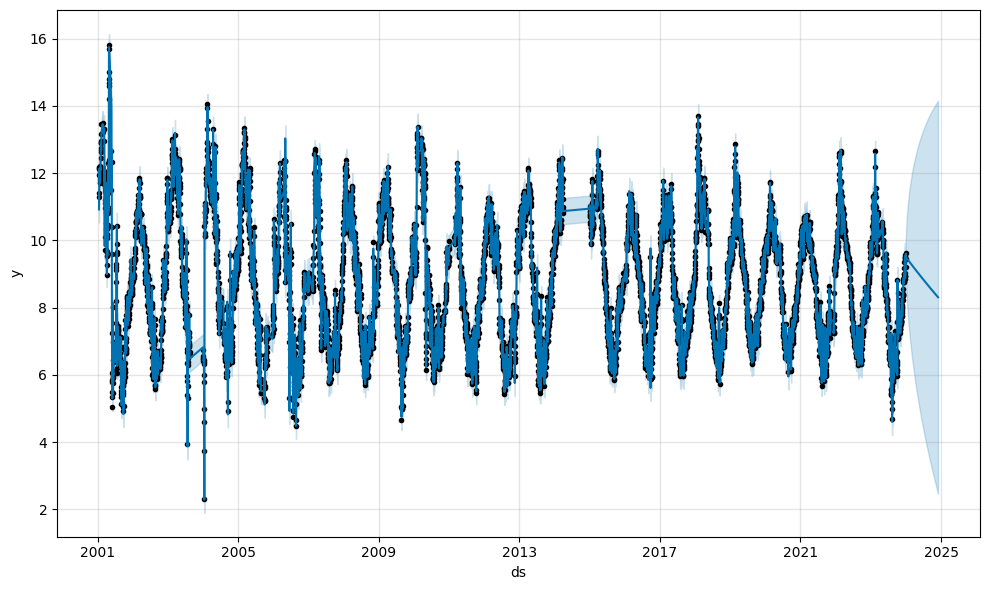

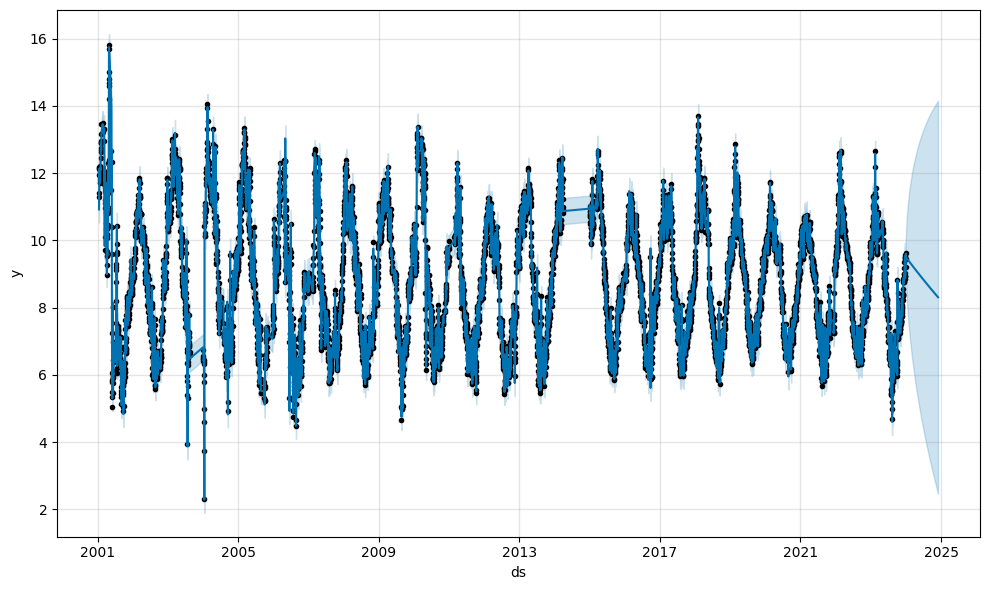

In [ ]:
fig1 = m.plot(forecast)
fig1

In [ ]:
plot_plotly(m, forecast)